In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device()#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=False, 
    log_transform=False,
    scale_method=None,

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:7

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:7)
# edge_index               (2, 32798)               Tensor (cuda:7)
# edge_attr                (32798, 16)              Tensor (cuda:7)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:7)
# x                        (562, 4383, 1)           Tensor (cuda:7)
# y                        (562,)                   Tensor (cuda:7)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 16

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features
_x = _batch.x.view(_batch.batch_size, int(_batch.x.shape[0]/_batch.batch_size), -1)

In [3]:
_batch.keys()

['x', 'batch', 'edge_attr', 'sample_id', 'y', 'edge_index', 'pe', 'ptr']

In [4]:
{k: getattr(_batch, k) for k in _batch.keys()}

{'x': tensor([[ 1457.],
         [ 2088.],
         [ 2100.],
         ...,
         [ 6559.],
         [18252.],
         [ 1536.]], device='cuda:7'),
 'batch': tensor([ 0,  0,  0,  ..., 63, 63, 63], device='cuda:7'),
 'edge_attr': tensor([[0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.]], device='cuda:7'),
 'sample_id': tensor([534,  85, 340, 531, 360, 294, 274, 145, 390, 190, 178,  66, 290, 539,
         446, 427, 522, 206,  12, 443, 224,  59, 104, 480, 108, 542,  73, 507,
         259, 297, 216, 510,  53,  25, 249,  20, 268, 303,  55,   6,  30,  86,
         400,   8, 460, 236, 473, 226, 239, 421, 332, 483,  42, 200, 523, 417,
         441, 466, 299, 372, 442, 353, 528, 283], device='cuda:7'),
 'y': tensor([5, 0, 3, 5, 3, 2, 2, 1, 3, 1, 1, 0, 2, 5, 4, 3, 5, 2, 0, 4, 2, 0, 0, 5,
      

---

In [5]:
from modules.utils import reshape, filter_kwargs
from modules.model import cloneable, get_layers, attn_dims

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import MessagePassing, GCNConv, GATConv

from torch import Tensor
from torch_geometric.data import Batch, Data # Batch is a subclass of Data
from typing import Literal, Optional, Union

* autoencoder:
    * **encoder** = wrapper w/ batch handling, forward for:
        * **node_encoder**
            * MLP, GCN, GAT, GraphTransformer
            * x (b,n,F) --> h (b,n,E)
        * **set_pool** (optional)
            * MeanPool, WtPool/AttnPool, TransformerPool
            * h (b,n,E) --> h_ns (b,n+s,E)
        * **set_encoder** (if set)
            * MLP, (Transformer)
            * dims unchanged
        * **global_pool**
            * MeanPool, WtPool/AttnPool, TransformerPool
            * h (b,n,E) --> z (b,1,E); or 
            * h_ns (b,n+s,E)
                * --split--> h_node (b,n,E), h_set (b,s,E)
                * --pool--> z_node, z_set (b,1,e)
                * --concat--> z_twin (b,2,E)
    

    * **latent** = maps encoder output to single z
        * if twin, mean pool: z_twin (b,2,E) --> z (b,1,e)
        * squeeze: z (b,1,e) --> z (b,e)
        * (if vae, perform reparameterization)


    * **decoder**
        * expand: z (b,e) --> (b,n*E) --reshape--> h^ (b,n,E)
        * if direct predict: h^ (b,n,E) --> x^ (b,n,1)
        * elif NB predict:
            * param est: h^ (b,n,E) --> (b,n,3) --chunk--> mu, theta, bias (b,n,1)
            * predict: x^ = mu + bias

* loss:
    * **reconstruction**
        * MSE, MAE
        * x (batch), x_recon (decoder)

    * **negative binomial loss** (optional)

    * **twin similarity** (optional)
        * cosine, CCA, Barlow Twins
        * z_node, z_set (global pool)

* major comparisons:
    * baseline config:
        * MLP node_encoder
        * no set_pool
        * no global_pool
        * direct predict decoder

    1. (2) NB loss: direct predict vs. NB predict w/ NB loss vs. 
        * **use best** decoder + configs going forward

    3. (3-5) node vs. set_pool + variants: none, MeanPool, WtPool/AttnPool, (TransformerPool)
        * impact of using set_pool on perf. (get baseline)
        * still use Wt/AttnPool going fwd. (allows node-set attn. analyses)

    4. (2-6) twin loss: none, cosine, (MSE/MAE, CCA, Barlow Twins)
        * visualize differences in embeddings (node, set, twin) to interpret/justify
        * **use best** sim loss going fwd.

    5. (2-4) global_pool variants: MeanPool, WtPool/AttnPool, (TransformerPool)
        * impact on using Wt/AttnPool on perf. (get baseline)
        * visualize differences in attn,weights,embeddings: does model prioritize one or the other?
        * still use Wt/AttnPool going fwd. (allows analyses)

    6. (3-4) node_encoder variants: MLP, GCN, GAT, (GraphTransformer)
        * impact on perf., use attn for analyses still
        * does graph information impact performance?
        * can graph information aid analyses?

    



    


In [6]:
def input_to_dict(input):
    if isinstance(input, Tensor): # x (Tensor) only
        data = {'x':input}
    elif isinstance(input, Data): # PyG Data or DataBatch
        data = {key: getattr(input, key) for key in input.keys()}
    elif isinstance(input, dict): # predefined dict
        data = input
    else:
        raise TypeError(f'unsupported input type: {type(input)}')
    return data

In [7]:
@cloneable
class Sequential(nn.Module):
    def __init__(
        self,
        in_channels:int, 
        out_channels:int, 
        layer_class:nn.Module, 
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,
        layer_kwargs:dict={},
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.layers = get_layers(
            in_channels,
            out_channels,
            layer_class,
            hidden_dims,
            act_fn,
            norm_fn,
            end_fn,
            layer_kwargs
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # get input as kwargs dict
        data = input_to_dict(input)

        # extract x as positional, update kwargs if provided
        x = data['x']
        data = {k:v for k,v in data.items() if k!='x'}
        data.update(kwargs)

        out = {}

        # forward pass through layers
        for layer in range(len(self.layers)):
            layer_out = filter_kwargs(self.layers[layer])(x, **data)

            # filter output if tuple
            if isinstance(layer_out, torch.Tensor):
                x = layer_out
                
            elif isinstance(layer_out, tuple):
                x = layer_out[0]
                remaining = layer_out[1:]

                if len(remaining) == 1: 
                    out[f'out_{layer}'] = remaining[0] # unpacks tuple if 1
                else:
                    out[f'out_{layer}'] = remaining # keeps tuple if 2+

            else:
                raise TypeError(f'unsupported layer output type: {type(layer_out)}')
            
        if return_dict:
            out['x'] = x
            return out
        else:
            return x

In [8]:
gnn = Sequential(
    in_channels=brca.num_node_features,
    out_channels=16,
    layer_class=GATConv
)

out = gnn(_batch, return_dict=True, return_attention_weights=None)
out

{'x': tensor([[  442.7987, -3076.1755, -1743.7482,  ..., -2463.9868, -2230.2095,
           2200.5312],
         [  442.7987, -3076.1755, -1743.7482,  ..., -2463.9868, -2230.2095,
           2200.5312],
         [  742.4114, -5157.6201, -2923.6274,  ..., -4131.2041, -3739.2451,
           3689.4856],
         ...,
         [  474.5616, -3296.8357, -1868.8308,  ..., -2640.7334, -2390.1870,
           2358.3799],
         [ 1320.5820, -9174.2412, -5200.4727,  ..., -7348.4780, -6651.2720,
           6562.7612],
         [  111.1338,  -772.0597,  -437.6466,  ...,  -618.4124,  -559.7389,
            552.2902]], device='cuda:7', grad_fn=<AddBackward0>)}

In [9]:
@cloneable
class SetPooling(nn.Module):
    @filter_kwargs
    def __init__(self, mask:Tensor, num_features:int, *args, **kwargs):
        '''
        mask: (nodes, sets)
        should adapt to have edge features in future
        '''
        super().__init__()
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.num_features = num_features

    def forward(self, input:Union[Data, Tensor, dict], concat:bool=True, return_dict:bool=False):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, nodes, features)
        x_node = reshape(x=data['x'], to='b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)

        # pool x to (batch, set, features)
        x_set = self.pool(x_node)

        # concat to (batch, nodes + sets, features)
        x = torch.cat([x_node, x_set], dim=1) if concat else x_set

        return {'x':x} if return_dict else x

    def pool(self, x:Tensor):
        '''
        define in child class. default: mean
        '''
        # sum across sets (add pool)
        x_set = torch.einsum('bnf,ns->bsf', x, self.mask)

        # nodes per set (denom); clamp for sum=0 case
        nodes_per_set = self.mask.sum(dim=0).clamp(min=1).view(1,self.num_sets,1)

        # return mean (sum per set/total per set)
        return x_set / nodes_per_set

In [10]:
embed_dim, head_dim, num_heads = attn_dims(head_dim=16, num_heads=2)

gnn = Sequential(
    in_channels=brca.num_node_features,
    out_channels=embed_dim,
    layer_class=nn.Linear
)

sp = SetPooling(
    mask=brca.mask,
    num_features=embed_dim
)

mlp = Sequential(
    in_channels=embed_dim,
    out_channels=embed_dim,
    layer_class=nn.Linear
)

h_n = gnn(_batch)
print(h_n.shape)

h_ns = sp(h_n, concat=False)
print(h_ns.shape)


mlp(h_ns).shape



torch.Size([280512, 32])
torch.Size([64, 305, 32])


torch.Size([64, 305, 32])

In [11]:
@cloneable
class TempEncoder(nn.Module):
    def __init__(self, mask:Tensor, num_features:int, node_encoder:nn.Module, set_pooling:nn.Module=None, mlp:nn.Module=None, method:Literal['node','set','twin']='node', *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.num_nodes = mask.shape[0]
        self.num_features = num_features
        self.method = method

        self.node_encoder = node_encoder.clone()
        self.set_pooling = set_pooling.clone() if set_pooling is not None else None
        self.mlp = mlp.clone() if mlp is not None else None

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False): 
        # node embedding
        h = self.node_encoder(input)
        h = reshape(h, 'b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)

        # set pooling
        if self.method == 'node':
            h = self.mlp(h) if self.mlp is not None else h # h_n

        if self.method == 'set':
            assert self.set_pooling is not None, "set_pooling must be provided for method='set'"
            h = self.set_pooling(h, concat=False)
            h = self.mlp(h) if self.mlp is not None else h # h_s

        elif self.method == 'twin':
            assert self.set_pooling is not None, "set_pooling must be provided for method='twin'"
            h = self.set_pooling(h, concat=True)
            h = self.mlp(h) if self.mlp is not None else h # h_ns

        return {'x':h} if return_dict else h

In [12]:
embed_dim, head_dim, num_heads = attn_dims(head_dim=16, num_heads=2)

encoder = TempEncoder(
    mask=brca.mask,
    num_features=embed_dim,
    node_encoder=gnn,
    set_pooling=sp,
    # mlp=mlp,
    method='twin'
)

h = encoder(_batch)
h.shape

torch.Size([64, 4688, 32])

In [13]:
@cloneable
class Latent(nn.Module):
    def __init__(self, mask:Tensor, num_features:int, pooling:nn.Module, method:Literal['node','set','twin']='node', fwd:Literal['node','set','twin','twin_pool']=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if fwd == None:
            fwd = method # default: fwd matches method
        self.num_features = num_features
        self.method = method
        self.fwd = fwd
    
        # determine n dim (for reshaping)
        num_nodes, num_sets = mask.shape
        if method == 'node':
            self.n_dim = num_nodes
            self.split_dim = None
        elif method == 'set':
            self.n_dim = num_sets
            self.split_dim = None
        elif method == 'twin':
            self.n_dim = num_nodes + num_sets
            self.split_dim = [num_nodes, num_sets]
        else:
            raise TypeError(f'unsupported method: {method}')

        self.node_pool = pooling.clone(mask=torch.ones(num_nodes,1)) if (method == 'node' or method == 'twin') else None
        self.set_pool = pooling.clone(mask=torch.ones(num_sets,1)) if (method == 'set' or method == 'twin') else None
        self.twin_pool = pooling.clone(mask=torch.ones(2,1)) if fwd == 'twin' else None

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, n, features), where n is (nodes) or (nodes+sets)
        x = reshape(x=data['x'], to='b,n,f', num_nodes=self.n_dim, num_features=self.num_features)

        # pool
        if self.method == 'node':
            z_node = self.node_pool(x, concat=False)
            z_set = None
        elif self.method == 'set':
            z_node = None
            z_set = self.set_pool(x, concat=False)
        else: #self.method == 'twin'
            x_node, x_set = x.split(self.split_dim, dim=1) #split, pool sep
            z_node = self.node_pool(x_node, concat=False)
            z_set = self.set_pool(x_set, concat=False)

        # fwd
        if self.fwd == 'node':
            x = z_node
        elif self.fwd == 'set':
            x = z_set
        else: # self.fwd == 'twin' or 'twin_pool':
            x = torch.cat([z_node, z_set], dim=1)
            x = self.twin_pool(x, concat=False) if self.fwd == 'twin_pool' else x.mean(dim=1)

        # squeeze to (b,F)
        x = x.squeeze(1)
        z_node = z_node.squeeze(1) if z_node is not None else z_node
        z_set = z_set.squeeze(1) if z_set is not None else z_set

        # return
        return {'x':x, 'z_node':z_node, 'z_set':z_set} if return_dict else (x, z_node, z_set)

In [14]:
method = 'twin'
embed_dim, head_dim, num_heads = attn_dims(head_dim=16, num_heads=2)

encoder = TempEncoder(
    mask=brca.mask,
    num_features=embed_dim,
    node_encoder=gnn,
    set_pooling=sp,
    mlp=mlp,
    method=method
)

h = encoder(_batch)

latent = Latent(
    mask=brca.mask,
    num_features=embed_dim,
    pooling=sp,
    method=method
)

z = latent(h)
print([f'{k}: {v.shape}' for k,v in z.items() if v is not None])

['x: torch.Size([64, 32])', 'z_node: torch.Size([64, 32])', 'z_set: torch.Size([64, 32])']


In [15]:
@cloneable
class Decoder(nn.Module):
    def __init__(
        self, 
        mask:Tensor,

        # transformer dims
        embed_dim:int=None, 
        head_dim:int=None, 
        num_heads:int=1, 

        # etc
        hidden_dims:list[int]=None, 
        lin_kwargs:dict={}, 
        mode:Literal['direct','nb']='direct',
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        embed_dim, _, _ = attn_dims(embed_dim, head_dim, num_heads)
        self.num_nodes = mask.shape[0]
        self.mode = mode

        # mode-specific out-layer
        assert mode in ['direct','nb'], f'unexpected mode {mode}'
        self.num_params = 1 # x_recon or bias
        self.num_params += 2 if mode == 'nb' else 0 # beta, gamma

        # layers       
        self.expand = Sequential(
            in_channels=embed_dim,
            out_channels=embed_dim * self.num_nodes,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            **lin_kwargs
        )
        
        self.estimate = Sequential(
            in_channels=embed_dim,
            out_channels=self.num_params,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            **lin_kwargs
        )

    def forward(self, input:Tensor, as_dict:bool=True, *args, **kwargs):
        '''
        reconstructs x and NB params. z in (b,E).
        '''
        # get input as kwargs dict
        data = input_to_dict(input)
        z = data['x']
        batch_size = z.shape[0]

        # transform sample --> (b,n,E) --> (b,n,params)
        z = self.expand(z).view(batch_size, self.num_nodes, -1)
        params = self.estimate(z)

        if self.mode == 'direct':
            mu = None
            theta = None
            bias = None
            x_recon = params

        else: # self.mode == 'nb':
            mu, theta, bias = params.chunk(self.num_params, dim=-1) # get (log) params
            mu = torch.exp(mu)
            theta = torch.exp(theta)
            x_recon = mu * torch.exp(bias) # keep bias signed

        if as_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta, 'bias':bias}
        else:
            return x_recon, mu, theta, bias



In [16]:
decoder = Decoder(
    mask=brca.mask,
    embed_dim=embed_dim,
    mode='nb'
)

decoder(z['x'])['bias']

tensor([[[ -560.5906],
         [  181.5659],
         [ -100.6378],
         ...,
         [  -77.4571],
         [ -465.0776],
         [ -254.3650]],

        [[-1100.1947],
         [  356.5165],
         [ -197.4696],
         ...,
         [ -151.9545],
         [ -912.7349],
         [ -499.1046]],

        [[ -749.3110],
         [  242.7529],
         [ -134.5036],
         ...,
         [ -103.5116],
         [ -621.6405],
         [ -339.9599]],

        ...,

        [[ -591.2811],
         [  191.5164],
         [ -106.1452],
         ...,
         [  -81.6942],
         [ -490.5385],
         [ -268.2847]],

        [[ -653.0892],
         [  211.5558],
         [ -117.2366],
         ...,
         [  -90.2274],
         [ -541.8147],
         [ -296.3182]],

        [[-1081.4434],
         [  350.4373],
         [ -194.1047],
         ...,
         [ -149.3656],
         [ -897.1787],
         [ -490.5999]]], device='cuda:7', grad_fn=<SplitBackward0>)

---

In [17]:
@cloneable
class AttentionSetPooling(SetPooling):
    def __init__(
        self, 
        mask:Tensor, 
        num_features:int,

        # lin 
        hidden_dims:list[int]=None,
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        *args, **kwargs
    ):
        super().__init__(mask, num_features, *args, **kwargs)

        self.lin = Sequential(
            in_channels=num_features,
            out_channels=self.num_sets,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def pool(self, x:Tensor):
        # compute masked scores, attention
        scores = self.lin(x).masked_fill(self.mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)

        # apply attention (weighted mean)
        x = torch.einsum('bnf,bns->bsf', x, attn)

        return x


In [18]:
embed_dim, head_dim, num_heads = attn_dims(head_dim=16, num_heads=2)

gnn = Sequential(
    in_channels=brca.num_node_features,
    out_channels=embed_dim,
    layer_class=nn.Linear,
    # hidden_dims=[64]
)

sp = AttentionSetPooling(
    mask=brca.mask,
    num_features=embed_dim,
    # hidden_dims=[64]
)

h_n = gnn(_batch)
print(h_n.shape)

h_ns = sp(h_n, concat=False)
print(h_ns.shape)

torch.Size([280512, 32])
torch.Size([64, 305, 32])


In [19]:
gnn

Sequential(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=32, bias=True)
  )
)

In [20]:
sp

AttentionSetPooling(
  (lin): Sequential(
    (layers): ModuleList(
      (0): Linear(in_features=32, out_features=305, bias=True)
    )
  )
)

---

In [21]:
@cloneable
class Encoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers; instance or predefined
        node_encoder:Union[nn.Module,Sequential]=None,
        set_pooling:SetPooling=None,

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node',
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        # dims
        self.mask = mask
        self.num_features = num_features
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method

        # node encoder; init new, or copy if provided
        if isinstance(node_encoder, type) and issubclass(node_encoder, nn.Module):
            self.node_encoder = Sequential(
                in_channels=self.num_features,
                out_channels=self.embed_dim,
                layer_class=node_encoder,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(node_encoder,(nn.Module, Sequential)):
            self.node_encoder = node_encoder.copy()
        else:
            raise TypeError(f'node_encoder must be a type, predefined nn.Module, or Sequential, got: {type(node_encoder)}')

        # set pooling
        if isinstance(set_pooling, type) and issubclass(set_pooling, SetPooling):
            self.set_pooling = set_pooling(
                mask=self.mask,
                num_features=self.embed_dim,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(set_pooling, (nn.Module, SetPooling)):
            self.set_pooling = set_pooling.copy()
        else:
            self.set_pooling = None

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # node embedding
        h = self.node_encoder(input, return_dict=return_dict, **kwargs)
        h = input_to_dict(h) # extract if dict
        x = reshape(h['x'], 'b,n,f', num_nodes=self.num_nodes, num_features=self.embed_dim)

        if self.method == 'set':
            assert self.set_pooling is not None, "set_pooling must be provided for method='set'"
            x = self.set_pooling(x, concat=False)

        elif self.method == 'twin':
            assert self.set_pooling is not None, "set_pooling must be provided for method='twin'"
            x = self.set_pooling(x, concat=True)

        if return_dict:
            h['x'] = x
            return h
        else:
            return x

In [22]:
@cloneable
class Latent(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # mlp
        mlp:Union[bool,Sequential]=False,
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # pooling
        global_pooling:SetPooling=None,
        method:Literal['node','set','twin']='node',
        fwd:Literal['node','set','twin','twin_pool']=None,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        # dims
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method
        
        # default fwd
        if fwd == None:
            fwd = method
        self.fwd = fwd

        # determine n dim (for reshaping)
        num_nodes, num_sets = mask.shape
        if method == 'node':
            self.n_dim = num_nodes
            self.split_dim = None
        elif method == 'set':
            self.n_dim = num_sets
            self.split_dim = None
        elif method == 'twin':
            self.n_dim = num_nodes + num_sets
            self.split_dim = [num_nodes, num_sets]
        else:
            raise TypeError(f'unsupported method: {method}')
        
        # mlp
        if mlp:
            self.mlp = Sequential(
                in_channels=self.embed_dim,
                out_channels=self.embed_dim,
                layer_class=nn.Linear,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(mlp, (nn.Module, Sequential)):
            self.mlp = mlp.clone()
        else:
            self.mlp = None

        # pooling
        def init_pooling(pooling, mask, condition):
            if condition:
                if isinstance(pooling, type) and issubclass(pooling, SetPooling):
                    return pooling(
                        mask=mask,
                        num_features=self.embed_dim,
                        hidden_dims=hidden_dims,
                        act_fn=act_fn,
                        norm_fn=norm_fn,
                        end_fn=end_fn
                    )
                elif isinstance(pooling, (nn.Module, SetPooling)):
                    return pooling.copy(mask=mask)
                else:
                    raise TypeError(f'global_pooling must be a type, predefined nn.Module, or SetPooling, got: {type(global_pooling)}')
            else:
                return None

        self.node_pool = init_pooling(global_pooling, torch.ones(self.num_nodes,1), method in ('node','twin'))
        self.set_pool = init_pooling(global_pooling, torch.ones(self.num_sets,1), method in ('set','twin'))
        self.twin_pool = init_pooling(global_pooling, torch.ones(2,1), fwd == 'twin_pool')

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, n, features), where n is (nodes) or (nodes+sets)
        x = reshape(x=data['x'], to='b,n,f', num_nodes=self.n_dim, num_features=self.embed_dim)

        # mlp
        x = self.mlp(x) if self.mlp is not None else x

        # pool
        if self.method == 'node':
            z_node = self.node_pool(x, concat=False)
            z_set = None
        elif self.method == 'set':
            z_node = None
            z_set = self.set_pool(x, concat=False)
        else: #self.method == 'twin'
            x_node, x_set = x.split(self.split_dim, dim=1) #split, pool sep
            z_node = self.node_pool(x_node, concat=False)
            z_set = self.set_pool(x_set, concat=False)

        # fwd
        if self.fwd == 'node':
            x = z_node
        elif self.fwd == 'set':
            x = z_set
        else: # self.fwd == 'twin' or 'twin_pool':
            x = torch.cat([z_node, z_set], dim=1)
            x = self.twin_pool(x, concat=False) if self.fwd == 'twin_pool' else x.mean(dim=1)

        # squeeze to (b,F)
        x = x.squeeze(1)
        z_node = z_node.squeeze(1) if z_node is not None else z_node
        z_set = z_set.squeeze(1) if z_set is not None else z_set

        # return
        return {'x':x, 'z_node':z_node, 'z_set':z_set} if return_dict else (x, z_node, z_set)






        

In [23]:
# if expand
    # expand: (b,E) -> (b,n*E) -> (b,n,E)

    # if shared
        # estimate: (b,n,E) -> (b,n, params) -> params * (b,n)
    # else not shared
        # est_param: (b,n,E) -> (b,n), per param

# else no expand
    # if shared
        # estimate: (b,E) -> (b,n*params) -> params * (b,n)
    # else not shared
        # est_param: (b,E)-> (b,n), per param


###

# expand, shared:
    # expand: E to n*E
    # estimate: E to params

# expand, not shared:
    # expand: E to n*E
    # estimate: E to 1 (per param)

# no expand, shared:
    # estimate: E to n*params

# no expand, not shared
    # estimate: E to n (per param)

a = 2
a *= 0
print(a)

0


In [24]:
@cloneable
class Decoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layer args
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # decoder
        expand_mlp:bool=False,
        shared_mlp:bool=True,
        fit_nb:bool=False,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.expand_mlp = expand_mlp
        self.shared_mlp = shared_mlp
        self.fit_nb = fit_nb

        self.num_params = 1 # x_recon or bias (nb)
        self.num_params += 2 if self.fit_nb else 0 # mu, theta

        # expand mlp: make per-node embeddings (True) or direct from z
        if self.expand_mlp:
            self.expand = Sequential(
                in_channels=self.embed_dim,
                out_channels=self.num_nodes * self.embed_dim,
                layer_class=nn.Linear,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        else:
            self.expand = None

        # shared mlp: params share a single mlp, or indv. per param
        if self.shared_mlp: # params (expand) or n*params (no expand)
            estimate_channels = self.num_params if self.expand_mlp else self.num_nodes * self.num_params
        else: # 1 (expand) or n*1 (no expand)
            estimate_channels = 1 if self.expand_mlp else self.num_nodes
        self.estimate = Sequential(
            in_channels=self.embed_dim,
            out_channels=estimate_channels, 
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

        # nb
        if self.fit_nb and not self.shared_mlp:
            self.est_mu = self.estimate.clone()
            self.est_theta = self.estimate.clone()

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)
        z = data['x']
        batch_size = z.shape[0]

        # expand
        if self.expand_mlp:
            z = self.expand(z) # (b,n*E)
            z = z.view(batch_size, self.num_nodes,-1) # (b,n,E)
        
        # nb
        if self.fit_nb:
            if self.shared_mlp:
                est = self.estimate(z) # expanded (b,n,3) or non-expanded (b,n*3)
                if not self.expand_mlp: # force to (b,n,3) if non-expanded
                    est = est.view(batch_size, self.num_nodes, self.num_params)
                mu, theta, bias = est.chunk(self.num_params, dim=-1) # each (b,n,1)

            else: # individual MLPs, each (b,n,1)
                mu = self.est_mu(z)
                theta = self.est_theta(z)
                bias = self.estimate(z)

            # transform
            # mu = torch.exp(mu).view(-1,1)
            # theta = torch.exp(theta).view(-1,1)
            # bias = torch.exp(bias).view(-1,1)

            #(b*n,1) to match input
            mu = mu.view(-1,1)
            theta = theta.view(-1,1)
            bias = bias.view(-1,1)
            x_recon = mu * bias

        # direct
        else:
            est = self.estimate(z)#.view(batch_size, self.num_nodes) # force to (b,n)
            mu = theta = bias = None
            x_recon = est.view(-1,1) #(b*n,1) to match input
            x_recon = torch.exp(x_recon)

        if return_dict:
            return {'x':x_recon, 'mu':mu, 'theta':theta, 'bias':bias} 
        else: 
            return x_recon, mu, theta, bias


In [25]:
#f,f,f: b,n,f

#T,f,f: b,n,f
#f,T,f: b,n,f
#f,f,T: b,n

#T,T,f = b,n,f
#T,f,T = b,n,f
#f,T,T = b,n,f

#T,T,T = b,n,f







In [26]:
embed_dim = 16
hidden_dims=[64]
method='twin'
fwd=None

encoder = Encoder(
    mask=brca.mask,
    num_features=brca.num_node_features,
    embed_dim=embed_dim,
    node_encoder=nn.Linear,
    set_pooling=AttentionSetPooling,
    # mlp=True,
    hidden_dims=hidden_dims,
    # norm_fn='layer',
    method=method
)

latent = Latent(
    mask=brca.mask,
    embed_dim=embed_dim,
    global_pooling=AttentionSetPooling,
    hidden_dims=hidden_dims,
    method=method,
    fwd=fwd
)

decoder = Decoder(
    mask=brca.mask,
    embed_dim=embed_dim,
    hidden_dims=hidden_dims,
    expand_mlp=True,
    shared_mlp=False,
    fit_nb=True
)

h = encoder(_batch)
print(f'h:\t', h.shape)

z = latent(h)
for key in z.keys():
    print(f'{key}:\t {z[key].shape}') if z[key] is not None else print(z[key])

recon = decoder(z)
for key in recon.keys():
    print(f'{key}:\t {recon[key].shape}') if recon[key] is not None else print(f'{key}:\t {recon[key]}')

h:	 torch.Size([64, 4688, 16])
x:	 torch.Size([64, 16])
z_node:	 torch.Size([64, 16])
z_set:	 torch.Size([64, 16])
x:	 torch.Size([280512, 1])
mu:	 torch.Size([280512, 1])
theta:	 torch.Size([280512, 1])
bias:	 torch.Size([280512, 1])


In [27]:
# print(encoder)
# print(latent)
print(decoder)

Decoder(
  (expand): Sequential(
    (layers): ModuleList(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=70128, bias=True)
    )
  )
  (estimate): Sequential(
    (layers): ModuleList(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (est_mu): Sequential(
    (layers): ModuleList(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (est_theta): Sequential(
    (layers): ModuleList(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [28]:
@cloneable
class Autoencoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None, # encoder
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers
        node_encoder:Union[nn.Module,Sequential]=None, # encoder
        pooling:SetPooling=None, # encoder (set), latent (global)
        mlp:Union[bool,Sequential]=False, # latent

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node', # encoder, latent
        fwd:Literal['node','set','twin','twin_pool']=None, # latent
        expand_mlp:bool=False, # decoder
        shared_mlp:bool=True, # decoder
        fit_nb:bool=False, # decoder
        log_transform:bool=True # autoencoder
    ):
        super().__init__()
        self.log_transform = log_transform

        # dims
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # modules
        self.encoder = Encoder(
            mask, num_features, embed_dim, head_dim, num_heads,
            node_encoder, pooling,
            hidden_dims, act_fn, norm_fn, end_fn,
            method
        )

        self.latent = Latent(
            mask, embed_dim, head_dim, num_heads,
            mlp,
            hidden_dims, act_fn, norm_fn, end_fn,
            pooling, method, fwd
        )

        self.decoder = Decoder(
            mask, embed_dim, head_dim, num_heads,
            hidden_dims, act_fn, norm_fn, end_fn,
            expand_mlp, shared_mlp, fit_nb
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        if self.log_transform:
            data['x'] = torch.log2(data['x']+1)

        # return tensor h (h_n, h_s, or h_ns)
        h = self.encoder(data, return_dict=False) # return_attention_weights=None

        # get z
        z, z_node, z_set = self.latent(h, return_dict=False)

        # get recon
        x_recon, mu, theta, bias = self.decoder(z, return_dict=False)

        if return_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta, 'z_node':z_node, 'z_set':z_set}
        else:
            return x_recon, mu, theta, z_node, z_set

        

        

    

In [29]:
ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features,
    embed_dim=16,
    num_heads=2,
    node_encoder=GATConv,
    pooling=AttentionSetPooling,
    mlp=True,
    norm_fn='layer',
    fit_nb=False,
    method='node'
)

out = ae(_batch, return_dict=True)
print(out.keys())

dict_keys(['x_recon', 'mu', 'theta', 'z_node', 'z_set'])


In [30]:
out.get('x_recon')

tensor([[inf],
        [inf],
        [inf],
        ...,
        [0.],
        [inf],
        [0.]], device='cuda:7', grad_fn=<ExpBackward0>)

In [31]:
_batch.get('x')

tensor([[ 1457.],
        [ 2088.],
        [ 2100.],
        ...,
        [ 6559.],
        [18252.],
        [ 1536.]], device='cuda:7')

In [32]:
from modules.train import Loader, Trainer
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

class Log2ReconTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        data = input_to_dict(batch)
        x = data.get('x')
        x = torch.log2(x+1)

        # forward pass
        out = self.model(batch)
        x_recon = out.get('x_recon')
        x_recon = torch.log2(x_recon+1)

        # compute loss
        loss = self.loss_fn(x, x_recon)

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([batch['x'] for batch in batch_log['batch']])
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']])
        # mu = torch.cat([batch['mu'] for batch in batch_log['out']])
        # theta = torch.cat([batch['theta'] for batch in batch_log['out']])

        # scale outputs to log2        
        log2_x = torch.log2(x + 1)
        log2_x_recon = torch.log2(x_recon + 1)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            # 'mu': mu.cpu().numpy(),
            # 'theta': theta.cpu().numpy(),
        }

        return metrics, values

In [45]:
ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features, # encoder
    # embed_dim=None,
    head_dim=32,
    num_heads=8,

    # layers
    node_encoder=nn.Linear, # encoder
    pooling=AttentionSetPooling, # encoder (set), latent (global)
    mlp=True, # latent

    # layer params
    hidden_dims=[64,64,64], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,

    # etc
    method='node', # encoder, latent
    fwd=None, # latent
    expand_mlp=True, # decoder
    shared_mlp=False, # decoder
    fit_nb=False, # decoder
    log_transform=True # autoencoder
)

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=64
)

trainer = Log2ReconTrainer(
    model=ae,
    loader=loader,
    num_epochs=200,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss','mae','rmse', 'r2'],
)

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [01:45<00:00,  1.89it/s, Epoch 199     Train: loss=1.6557    mae=0.8914    rmse=1.2830    r2=0.7948        Val: loss=1.6813    mae=0.8928    rmse=1.3192    r2=0.7850]   

Test	 loss=1.6160    mae=0.8865    rmse=1.2936    r2=0.7863



In [46]:
trainer.test_metrics

{'loss': 1.6160276532173157,
 'mean': -0.15702605247497559,
 'std': 1.2839967012405396,
 'mae': 0.8864589929580688,
 'mse': 1.6733002662658691,
 'rmse': 1.2935611009597778,
 'r2': 0.7862794399261475}

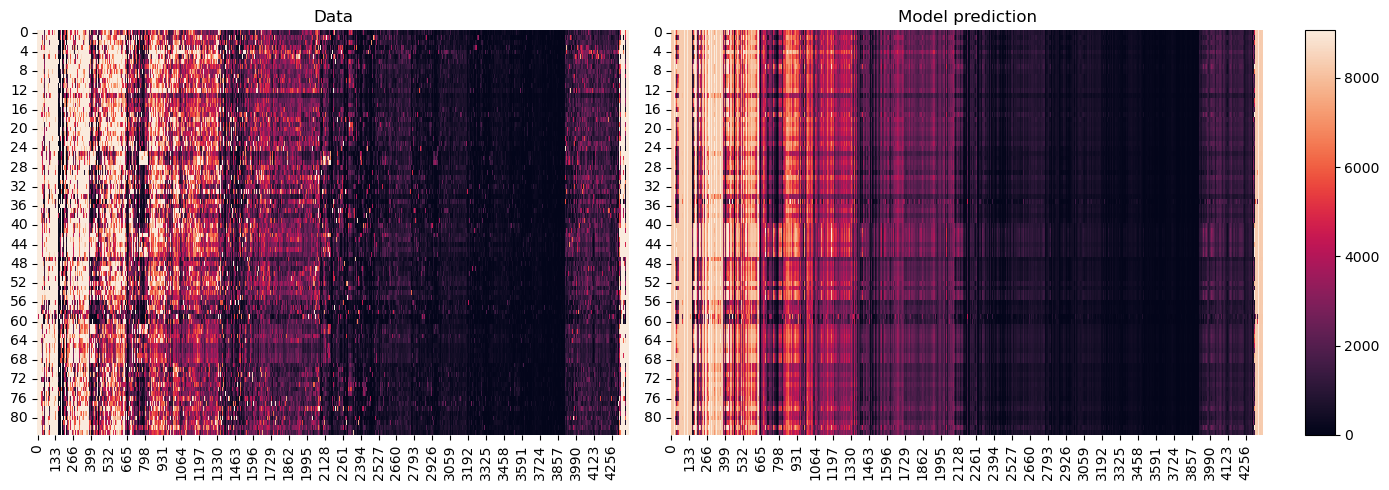

In [47]:
import numpy as np
import scipy.cluster.hierarchy as sch

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

x_in = trainer.test_values['x'].reshape(-1,brca.num_nodes)
x_out = trainer.test_values['x_recon'].reshape(-1,brca.num_nodes)

# Cluster rows
row_linkage = sch.linkage(x_in, method='average')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
row_order = row_dendro['leaves']

# Cluster columns
col_linkage = sch.linkage(x_in.T, method='average')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
col_order = col_dendro['leaves']

# Reorder
x_in = x_in[np.ix_(row_order, col_order)]
x_out = x_out[np.ix_(row_order, col_order)]

# Set up a gridspec layout: 1 row, 3 columns
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# Create subplots according to gridspec
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Common color scale
vmin = 0
vmax = np.percentile(x_in, 90)

# Plot heatmaps
sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax0.set_title('Data')
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax1.set_title('Model prediction')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()